In [33]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Processed data
Check the length of .csv file. Trim if needed

In [ ]:
name = "MGS5"
dir = f"/mnt/c/users/Elena/Desktop/Data_processing/280226_U2OS_live_FRAP2/results_{name}"
folder = Path(dir)

dfs = []  # list of DataFrames

for file in folder.glob("*.csv"):
    df = pd.read_csv(file)
    dfs.append(df)
    print(file, df.shape[0])

print(f"Loaded {len(dfs)} files.")

## Optional
Fix timescale

In [ ]:
for df in dfs:
    time = 0
    nframes = len(df)
    time_factors = [(37, 0.659), (float("inf"), 5)]

    for n in range(1, nframes + 1):
        for nframe, sec in time_factors:
            if n < nframe:
                time += sec
                df.loc[n-1, "Time"] = time
                break
            else:
                continue

## Trimmed dataframes

In [ ]:
N = 43
trimmed_dfs = {}
output_folder = f"/mnt/c/users/Elena/Desktop/Data_processing/280226_U2OS_live_FRAP2/results_{name}/trimmed"
for file in folder.glob("*.csv"):
    df = pd.read_csv(file)
    df_trimmed = df.iloc[:N].copy()
    trimmed_dfs[file.stem] = df_trimmed

    # save file
    df_trimmed.to_csv(output_folder +  f"/{file.stem}_trimmed.csv", index=False)


# Boxplots

In [41]:
def beautiful_boxplot(
    df_list,
    labels,
    ylabel=None,
    xlabel=None,
    title=None,
    log_scale=False,
    colors=None,         # list of colors per box (optional)
    dot_size=20,
    jitter=0.06,
    figsize=(4.8, 4.2),
    dpi=200,
    show=True
):
    """
    df_list : list of pandas Series (or 1D arrays)
    labels  : list of group names (same length as df_list)
    colors  : list of colors for each box (same length as df_list) or None
    """

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # Clean data
    data = [np.asarray(d.dropna()) for d in df_list]

    # Boxplot
    bp = ax.boxplot(
        data,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.2),
    )

    # Colors per box (or default)
    if colors is None:
        colors = ["lightgray"] * len(data)

    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.55)

    # Overlay jittered dots
    for i, y in enumerate(data, start=1):
        x = np.random.normal(loc=i, scale=jitter, size=len(y))
        ax.scatter(x, y, alpha=0.65, s=dot_size, linewidths=0)

    # Styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", direction="out", length=4, width=1, labelsize=9)

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=9)

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10)
    if title:
        ax.set_title(title, fontsize=11, pad=10)

    if log_scale:
        ax.set_yscale("log")

    fig.tight_layout()

    if show:
        plt.show()

    return fig, ax

In [54]:
paths = [
        "/mnt/c/users/Elena/Desktop/Data_processing/frap/easyFRAP_Final_Data_WT.csv",
        "/mnt/c/users/Elena/Desktop/Data_processing/frap/easyFRAP_Final_Data_MGS1.csv",
        "/mnt/c/users/Elena/Desktop/Data_processing/frap/easyFRAP_Final_Data_MGS2.csv",
        "/mnt/c/users/Elena/Desktop/Data_processing/frap/easyFRAP_Final_Data_MGS3.csv",
        "/mnt/c/users/Elena/Desktop/Data_processing/frap/easyFRAP_Final_Data_MGS4.csv",
        "/mnt/c/users/Elena/Desktop/Data_processing/frap/easyFRAP_Final_Data_MGS5.csv"
        ]

dfs = []  # list of DataFrames

for p in paths:
    df = pd.read_csv(p, skiprows=9, header=0)
    dfs.append(df)

print(f"Loaded {len(dfs)} files.")



Loaded 6 files.


In [57]:
labels=["WT", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]
args = [{'var': "T-half", 'ylabel':'Count', 'title':'T-half, sec'},
        {'var': "Mobile Fraction", 'ylabel':'Count', 'title': 'Mobile fraction, %'},
]

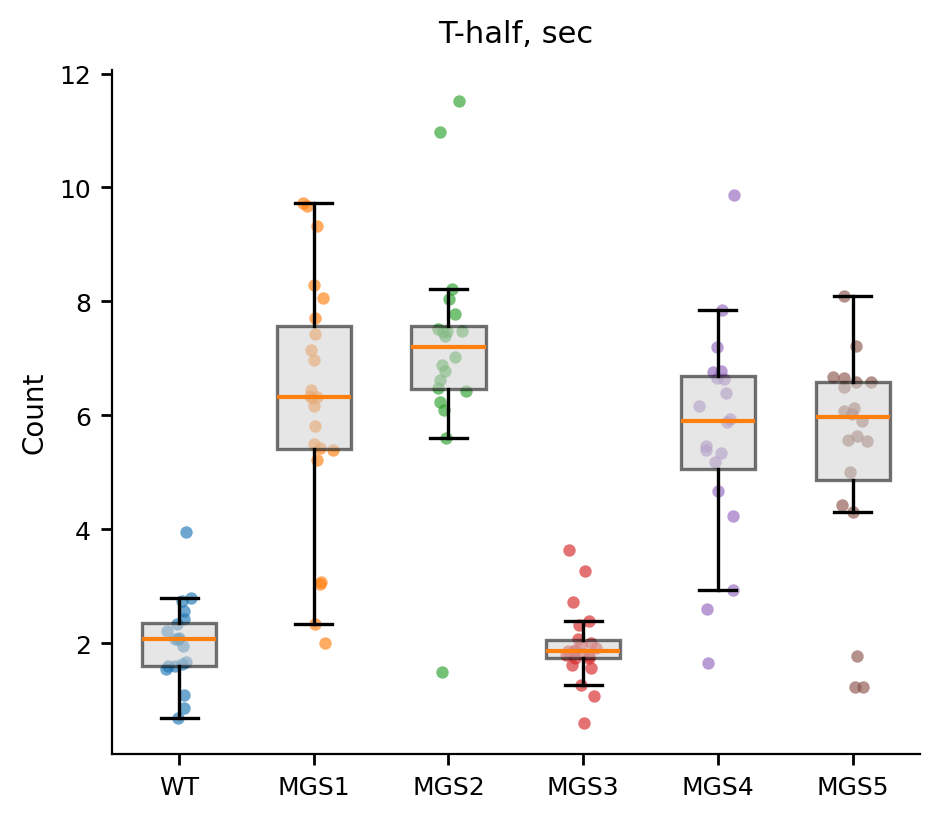

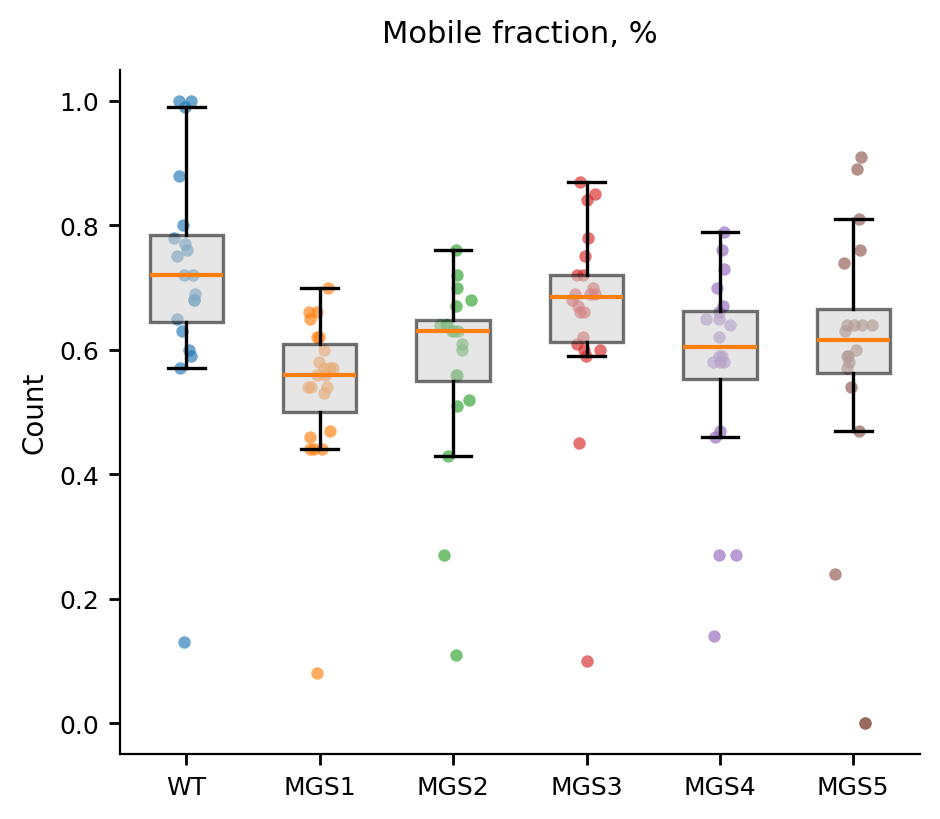

In [58]:
for arg in args:
    beautiful_boxplot(
        df_list=[
                dfs[0][arg['var']],
                dfs[1][arg['var']],
                dfs[2][arg['var']],
                dfs[3][arg['var']],
                dfs[4][arg['var']],
                dfs[5][arg['var']]
                ],
        labels=labels,
        ylabel=arg['ylabel'],
        title=arg['title']
    )